# 54 Modelo Híbrido — Ensamble ponderado por CV

Combina tres familias de modelos calibrados sobre los mismos datos:

| Componente | Tipo | Notebook de referencia |
|---|---|---|
| Ridge | Lineal regularizado (RidgeCV) | 51_linear_regression_def |
| RF Regularizado | Random Forest con `ccp_alpha` | 52_random_forest_3 |
| XGBoost | Gradient boosting | 53_boost_2 |

**Por qué RF Regularizado en lugar de Extra Trees:** Extra Trees con parámetros poco restringidos alcanza R²≈0.99 en train (memorización), lo que introduce alta varianza en el ensamble. El RF con `ccp_alpha` aplica poda por coste-complejidad, reduciendo el sobreajuste estructuralmente y aportando predicciones más estables como componente del híbrido.

**Ponderación automática:** los pesos se calculan como `1 / CV-RMSE` (normalizado) sobre el conjunto de entrenamiento. El modelo que mejor generaliza en CV recibe más peso, sin intervención manual.

**Robustez:** el notebook es completamente autónomo. No depende de que los notebooks 51–53 se hayan ejecutado previamente. Si se mejoran los hiperparámetros individuales, basta con actualizar `RF_PARAMS` y `XGB_PARAMS` en la celda de configuración.

In [8]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGB = False
    print("XGBoost no disponible — usando GradientBoostingRegressor como sustituto")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [9]:
# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE            = 42
TEST_SIZE               = 0.20
N_SPLITS                = 5
TARGET_COL              = "log_precio"
IQR_FACTOR              = 1.5
MIN_MUNICIPIO_REGISTROS = 10

RIDGE_ALPHAS = np.logspace(-3, 5, 200)

# ── Features del híbrido ─────────────────────────────────────────────────────
# Superconjunto que cubre los tres modelos componentes.
# Ridge: regulariza las menos útiles. Árboles: aprovechan todas.
# es_exterior_piso / tiene_ascensor_piso ya vienen pre-calculadas en el gold
# (= valor_raw × is_piso), por lo que se usan directamente sin renombrado.
FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "planta_num",            # numérico limpio (parse_planta aplicado en el gold)
    "es_exterior_piso",      # es_exterior × is_piso (pre-calculado en gold)
    "tiene_ascensor_piso",   # tiene_ascensor × is_piso (pre-calculado en gold)
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]

# ── Hiperparámetros de los modelos componentes ────────────────────────────────
# RF Regularizado: ccp_alpha poda el árbol por coste-complejidad, reduciendo
# el sobreajuste estructural respecto a Extra Trees sin restricciones.
RF_PARAMS = dict(
    n_estimators=400,
    max_depth=15,
    min_samples_leaf=10,
    max_features=0.4,
    ccp_alpha=0.001,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

GBR_PARAMS = dict(   # fallback si XGBoost no está disponible
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}
for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontró {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


In [10]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = df[TARGET_COL].between(q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr)
    print(f"  Outliers eliminados: {(~mask).sum()} / {len(df)} ({(~mask).mean()*100:.1f}%)")
    return df[mask].copy()


def build_X(df: pd.DataFrame) -> pd.DataFrame:
    """Construye la matriz de features: selecciona columnas del gold y agrupa municipios pequeños.

    El gold file ya tiene es_exterior_piso y tiene_ascensor_piso pre-calculadas
    (= valor_raw × is_piso) y planta_num como entero limpio, por lo que se
    usan directamente sin ningún renombrado.
    """
    df2 = df.copy()

    base_feats = []
    for f in FEATURES:
        if f in df2.columns and f not in base_feats:
            base_feats.append(f)

    # Agrupación de municipios con pocas observaciones
    mun_cols = [c for c in df2.columns if c.startswith("municipio_")]
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNICIPIO_REGISTROS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []

    all_feats = base_feats + [m for m in mun_final if m not in base_feats]
    all_feats = [f for f in all_feats if f in df2.columns]

    X = df2[all_feats].copy()
    return X.fillna(X.median(numeric_only=True))


def create_models() -> dict:
    """Instancia los tres modelos componentes del híbrido, cada uno en su pipeline."""
    ridge = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
        ("mdl", RidgeCV(alphas=RIDGE_ALPHAS, cv=N_SPLITS)),
    ])
    rf = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("mdl", RandomForestRegressor(**RF_PARAMS)),
    ])
    boost_estimator = XGBRegressor(**XGB_PARAMS) if HAS_XGB else GradientBoostingRegressor(**GBR_PARAMS)
    boost = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("mdl", boost_estimator),
    ])
    return {"ridge": ridge, "rf_reg": rf, "boost": boost}


def compute_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE":  float(mse),
        "RMSE": float(np.sqrt(mse)),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "MAPE": float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def get_cv_rmse(model, X, y) -> float:
    kf   = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    pred = cross_val_predict(model, X, y, cv=kf)
    return float(np.sqrt(mean_squared_error(y, pred)))


def plot_diagnostics(y_test, pred_test, title: str) -> None:
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.4, s=18, color="steelblue")
    lim = [min(y_test.min(), pred_test.min()) - 0.05,
           max(y_test.max(), pred_test.max()) + 0.05]
    ax.plot(lim, lim, "r--", lw=1.5, label="Predicción perfecta")
    ax.set(xlabel="Real (log_precio)", ylabel="Predicho (log_precio)",
           title="Real vs Predicho — test")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(pred_test, residuals, alpha=0.4, s=18, color="darkorange")
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set(xlabel="Predicho", ylabel="Residuo", title="Residuos vs Predicho — test")

    ax = axes[2]
    ax.hist(residuals, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", ls="--", lw=1.5)
    ax.set(xlabel="Residuo", ylabel="Frecuencia", title="Distribución residuos")

    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.



DATASET: SALE
Filas originales: 2469
  Outliers eliminados: 9 / 2469 (0.4%)
Filas tras limpieza: 2460
Features (52): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'muni

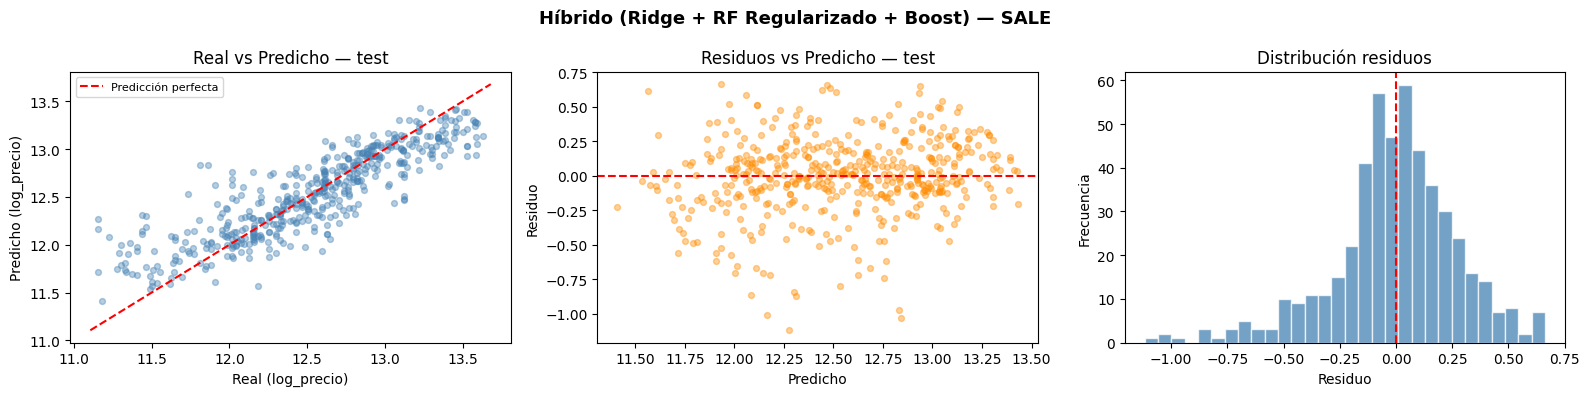


DATASET: RENT
Filas originales: 702
  Outliers eliminados: 18 / 702 (2.6%)
Filas tras limpieza: 684
Features (30): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'latitud', 'longitud', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Laredo', 'municipio_Piélagos', 'municipio_Santander', 'municipio_Torrelavega', 'municipio_otro', 'municipio_otros']
Train: 547 | Test: 137

── Calibrando pesos por CV-RMSE ────────────────────────────────────
  ridge         CV-RMSE = 0.16183
  rf_reg        CV-RMSE = 0.17281
  boo

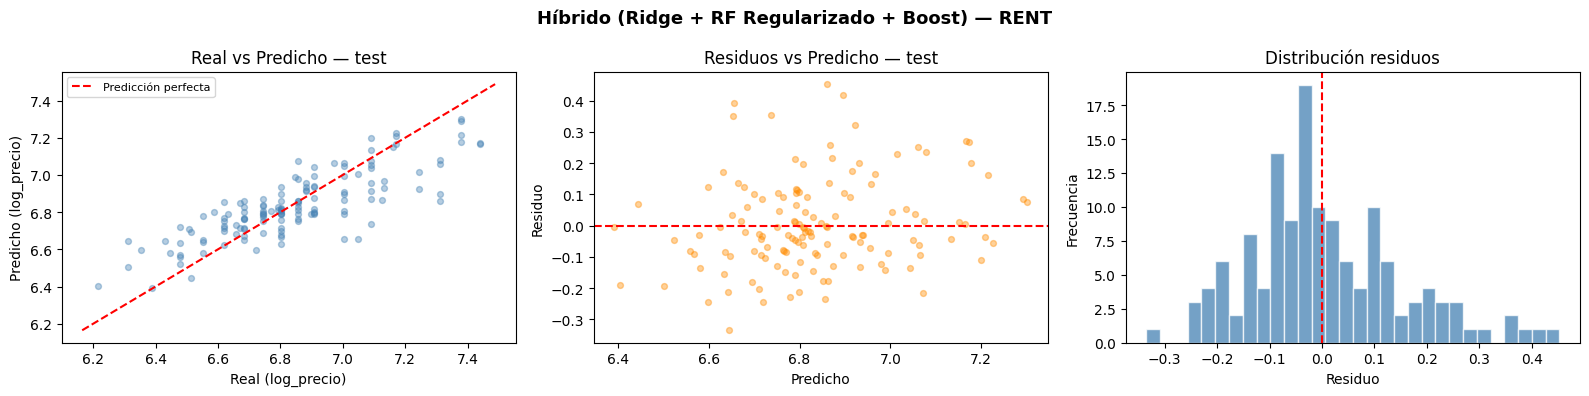

In [11]:
trained_state = {}   # guardará modelos, pesos y feature_cols por dataset
all_summary = []

for ds_name, ds_path in DATASETS.items():
    print()
    print("=" * 90)
    print(f"DATASET: {ds_name.upper()}")
    print("=" * 90)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(ds_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas originales: {len(df)}")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    X = build_X(df)
    y = df[TARGET_COL].copy()
    print(f"Features ({X.shape[1]}): {X.columns.tolist()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    # ── Pesos automáticos basados en CV-RMSE ──────────────────────────────────
    print("\n── Calibrando pesos por CV-RMSE ────────────────────────────────────")
    models   = create_models()
    cv_rmses = {}
    for name, model in models.items():
        cv_rmses[name] = get_cv_rmse(model, X_train, y_train)
        print(f"  {name:12s}  CV-RMSE = {cv_rmses[name]:.5f}")

    raw_w   = {k: 1.0 / v for k, v in cv_rmses.items()}
    total_w = sum(raw_w.values())
    weights = {k: v / total_w for k, v in raw_w.items()}
    print(f"  Pesos finales: { {k: round(v, 3) for k, v in weights.items()} }")

    # ── Entrenamiento final sobre train completo ───────────────────────────────
    for model in models.values():
        model.fit(X_train, y_train)

    # ── Predicciones híbridas ─────────────────────────────────────────────────
    pred_train = sum(weights[k] * models[k].predict(X_train) for k in models)
    pred_test  = sum(weights[k] * models[k].predict(X_test)  for k in models)

    train_m = compute_metrics(y_train, pred_train)
    test_m  = compute_metrics(y_test,  pred_test)

    # ── Métricas individuales vs híbrido ─────────────────────────────────────
    print("\n── Métricas test — individuales y híbrido ──────────────────────────")
    rows = []
    for name, model in models.items():
        m = compute_metrics(y_test, model.predict(X_test))
        rows.append({"modelo": name, "w": round(weights[name], 3), **m})
    rows.append({"modelo": "HÍBRIDO", "w": 1.0, **test_m})
    print(pd.DataFrame(rows).round(5).to_string(index=False))

    # ── Métricas train / test del híbrido ────────────────────────────────────
    print("\n── Métricas híbrido — train vs test ────────────────────────────────")
    print(pd.DataFrame([
        {"split": "train", **train_m},
        {"split": "test",  **test_m},
    ]).round(5).to_string(index=False))
    print(f"\n  delta RMSE test-train : {test_m['RMSE'] - train_m['RMSE']:+.5f}")
    print(f"  delta R2   train-test : {train_m['R2']  - test_m['R2']:+.5f}")

    plot_diagnostics(y_test, pred_test, f"Híbrido (Ridge + RF Regularizado + Boost) — {ds_name.upper()}")

    # ── Guardar estado para el estimador ─────────────────────────────────────
    trained_state[ds_name] = {
        "models":       models,
        "weights":      weights,
        "feature_cols": list(X_train.columns),
        "df_raw":       df,          # DataFrame completo (con columnas municipio_*)
    }

    all_summary.append({
        "dataset":    ds_name,
        "pesos":      str({k: round(v, 3) for k, v in weights.items()}),
        "train_RMSE": train_m["RMSE"], "train_R2": train_m["R2"],
        "test_RMSE":  test_m["RMSE"],  "test_R2":  test_m["R2"],
        "test_MAE":   test_m["MAE"],   "test_MAPE": test_m["MAPE"],
        "delta_RMSE": test_m["RMSE"] - train_m["RMSE"],
        "delta_R2":   train_m["R2"]  - test_m["R2"],
    })

In [12]:
print()
print("=" * 90)
print("RESUMEN GLOBAL — Modelo Híbrido")
print("=" * 90)
summary = pd.DataFrame(all_summary)
print(summary.round(5).to_string(index=False))
summary


RESUMEN GLOBAL — Modelo Híbrido
dataset                                             pesos  train_RMSE  train_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale {'ridge': 0.312, 'rf_reg': 0.322, 'boost': 0.366}     0.22189   0.83155    0.27968  0.75202   0.20516    0.01657     0.05779   0.07953
   rent {'ridge': 0.347, 'rf_reg': 0.325, 'boost': 0.327}     0.11494   0.77334    0.14637  0.66322   0.11235    0.01636     0.03143   0.11013


,dataset,pesos,train_RMSE,train_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,"{'ridge': 0.312, 'rf_reg': 0.322, 'boost': 0.366}",0.221889,0.831551,0.279682,0.752023,0.205160,0.016565,0.057793,0.079528
1,rent,"{'ridge': 0.347, 'rf_reg': 0.325, 'boost': 0.327}",0.114940,0.773344,0.146367,0.663218,0.112353,0.016362,0.031427,0.110127


---
## Estimador de precio para una vivienda concreta

Rellena los parámetros de la celda siguiente y ejecútala para obtener:
- **Precio de venta estimado** (modelo entrenado sobre `final_sale_idealistaAPI.csv`)
- **Alquiler mensual estimado** (modelo entrenado sobre `final_rent_idealistaAPI.csv`)

In [13]:
# ── Tabla de referencia geográfica por municipio ──────────────────────────────
# Se construye a partir de los datos de entrenamiento: para cada municipio
# calcula la mediana de las features geográficas y de mercado.

GEO_COLS = [
    "latitud", "longitud",
    "distancia_min_playa_km", "distancia_min_supermercado_km",
    "distancia_min_colegio_km", "precio_m2_municipio_media",
    "distancia_centro_municipio_km", "score_cercania_servicios",
]

municipio_ref = {}   # ds_name → DataFrame indexado por nombre de municipio

for ds_name, state in trained_state.items():
    df_raw   = state["df_raw"]
    mun_cols = [c for c in df_raw.columns if c.startswith("municipio_")]

    rows = []
    for mc in mun_cols:
        nombre = mc.replace("municipio_", "")
        subset = df_raw[df_raw[mc] == 1]
        if len(subset) == 0:
            continue
        row = {"municipio": nombre}
        for gc in GEO_COLS:
            row[gc] = subset[gc].median() if gc in subset.columns else np.nan
        rows.append(row)

    municipio_ref[ds_name] = pd.DataFrame(rows).set_index("municipio")

# Mostrar municipios disponibles
print("Municipios disponibles (SALE):")
print(sorted(municipio_ref["sale"].index.tolist()))
print()
print("Municipios disponibles (RENT):")
print(sorted(municipio_ref["rent"].index.tolist()))

Municipios disponibles (SALE):
['Ampuero', 'Barcena de Cicero', 'Camargo', 'Castro-Urdiales', 'Colindres', 'Cudon', 'El Astillero', 'Guarnizo', 'Laredo', 'Liendo', 'Limpias', 'Marina de Cudeyo', 'Miengo', 'Mogro', 'Noja', 'Ortuella', 'Piélagos', 'Polanco', 'Ribamontan al Mar', 'Ribamontan al Monte', 'Santa Cruz de Bezana', 'Santander', 'Santillana del Mar', 'Santoña', 'Santurtzi', 'Suances', 'Torrelavega', 'Villaescusa', 'Viveda', 'Voto', 'otro']

Municipios disponibles (RENT):
['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santander', 'Suances', 'Torrelavega', 'otro']


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  ESTIMADOR DE PRECIO — modifica los valores y ejecuta la celda
# ══════════════════════════════════════════════════════════════════════════════

# ── Datos comunes (obligatorios para cualquier tipología) ─────────────────────
MUNICIPIO      = "Santa Cruz de Bezana"   # Nombre exacto (ver lista de la celda anterior)
SUPERFICIE_M2  = 240            # m² construidos
N_DORMITORIOS  = 5             # Número de dormitorios
N_BANOS        = 3             # Número de baños
TIENE_GARAJE   = True         # ¿Incluye garaje?
OBRA_NUEVA     = True         # ¿Es obra nueva?
TIPOLOGIA      = "unifamiliar"        # "piso"  o  "unifamiliar"

# ── Solo para PISO (pon None si es unifamiliar) ───────────────────────────────
PLANTA         = None             # Planta (0=bajo, 1=primera…) → None si no aplica
ES_EXTERIOR    = None          # ¿Orientación exterior?      → None si no aplica
TIENE_ASCENSOR = None          # ¿Tiene ascensor?            → None si no aplica

# ── Solo para UNIFAMILIAR (pon None si es piso) ───────────────────────────────
# (actualmente el modelo no tiene features exclusivas de unifamiliar,
#  pero aquí se pueden añadir en el futuro)


# ── Lógica interna de predicción ─────────────────────────────────────────────
def _build_row(municipio, sup, dorm, banos, planta, exterior,
               ascensor, garaje, obra_nueva, tipologia,
               feature_cols, geo_stats):
    """
    Construye la fila de features para una vivienda.
    Los valores None se dejan como np.nan para que el SimpleImputer del
    pipeline los rellene con la mediana del conjunto de entrenamiento.
    """
    row = pd.Series(np.nan, index=feature_cols)

    def _set(k, v):
        if k in row.index and v is not None:
            row[k] = v

    # Numéricas básicas (siempre presentes)
    _set("superficie_construida_m2", sup)
    _set("numero_dormitorios",       dorm)
    _set("numero_banos",             banos)
    _set("tiene_garaje",             int(garaje))
    _set("obra_nueva",               int(obra_nueva))

    # Tipología
    _set("tipologia_unificada_piso",        1 if tipologia == "piso"        else 0)
    _set("tipologia_unificada_unifamiliar",  1 if tipologia == "unifamiliar" else 0)

    # Features de piso: planta_num es el entero limpio (coincide con el gold)
    _set("planta_num",          planta)
    _set("es_exterior_piso",    int(exterior)  if exterior  is not None else None)
    _set("tiene_ascensor_piso", int(ascensor)  if ascensor  is not None else None)

    # Interacción planta × sin ascensor: solo tiene sentido en pisos
    if tipologia == "piso" and planta is not None and ascensor is not None:
        _set("interaccion_planta_sin_ascensor_piso", planta * (1 - int(ascensor)))
    else:
        _set("interaccion_planta_sin_ascensor_piso", 0)

    # Ratios derivados
    _set("ratio_dormitorios_superficie", dorm / sup if sup > 0 else 0)
    _set("ratio_banos_superficie",       banos / sup if sup > 0 else 0)

    # Features geográficas tomadas de la mediana del municipio
    for col, val in geo_stats.items():
        _set(col, val)

    # Municipio one-hot (ceros en el resto, 1 en el del municipio elegido)
    mun_cols_in_features = [c for c in feature_cols if c.startswith("municipio_")]
    for c in mun_cols_in_features:
        row[c] = 0.0
    mun_col = f"municipio_{municipio}"
    if mun_col in row.index:
        row[mun_col] = 1.0
    elif "municipio_otros" in row.index:
        row["municipio_otros"] = 1.0   # municipio con pocas obs → agrupado

    return pd.DataFrame([row])


def estimar_precio(municipio, sup, dorm, banos, planta, exterior,
                   ascensor, garaje, obra_nueva, tipologia):
    desc = []
    if tipologia == "piso":
        if planta   is not None: desc.append(f"Planta {planta}")
        if exterior is not None: desc.append("exterior" if exterior else "interior")
        if ascensor is not None: desc.append("con ascensor" if ascensor else "sin ascensor")
    if garaje:     desc.append("garaje")
    if obra_nueva: desc.append("obra nueva")

    print()
    print("=" * 62)
    print(f"  VIVIENDA  {sup} m²  ·  {dorm} dorm.  ·  {banos} baños  —  {municipio}")
    print(f"  {tipologia.upper()}  ·  {' · '.join(desc) if desc else '—'}")
    print("=" * 62)

    for ds_name, state in trained_state.items():
        ref = municipio_ref.get(ds_name)
        if ref is None or municipio not in ref.index:
            disponibles = sorted(ref.index.tolist()) if ref is not None else []
            print(f"\n  [{ds_name.upper()}] Municipio '{municipio}' no encontrado.")
            print(f"  Municipios disponibles: {disponibles}")
            continue

        geo_stats    = ref.loc[municipio].to_dict()
        feature_cols = state["feature_cols"]
        X_pred = _build_row(municipio, sup, dorm, banos, planta, exterior,
                            ascensor, garaje, obra_nueva, tipologia,
                            feature_cols, geo_stats)

        models  = state["models"]
        weights = state["weights"]
        log_pred = sum(weights[k] * models[k].predict(X_pred)[0] for k in models)
        precio   = np.exp(log_pred)

        if ds_name == "sale":
            print(f"  Precio de venta estimado   : {precio:>12,.0f} €")
        else:
            print(f"  Alquiler mensual estimado  : {precio:>12,.0f} €/mes")

    print()


estimar_precio(
    MUNICIPIO, SUPERFICIE_M2, N_DORMITORIOS, N_BANOS,
    PLANTA, ES_EXTERIOR, TIENE_ASCENSOR, TIENE_GARAJE, OBRA_NUEVA, TIPOLOGIA
)


  VIVIENDA  240 m²  ·  5 dorm.  ·  3 baños  —  Santa Cruz de Bezana
  UNIFAMILIAR  ·  garaje · obra nueva
  Precio de venta estimado   :      629,486 €

  [RENT] Municipio 'Santa Cruz de Bezana' no encontrado.
  Municipios disponibles: ['Camargo', 'Castro-Urdiales', 'El Astillero', 'Laredo', 'Piélagos', 'Santander', 'Suances', 'Torrelavega', 'otro']

